In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

In [2]:
csv_files = {
    'pi'          : 'csv/pi.csv',
    'pi_python'   : 'csv/pi_python.csv',
    'radxa'       : 'csv/radxa.csv',
    'radxa_python': 'csv/radxa_python.csv',
    'hp'          : 'csv/hp.csv',
    'hp_python'   : 'csv/hp_python.csv',
}

In [3]:
dataframes = {
    name: pd.read_csv(filename, comment='#')
    for (name, filename) in csv_files.items()
}

## Simple linear regression

In [4]:
def apply_linear_regression(
    x,
    y,
    scale: bool = False,
    weights: np.array = 1.0):

    if scale:
        x = (x - np.mean(x)) / np.std(x)
        
    X = sm.add_constant(x)
    model = sm.WLS(y, X, weights=weights)
    results = model.fit()

    return results, model

The run with the raspberry pi seems to be consistent with a cacheless execution model:
$$ T(n) = \beta_0 + \beta_1 * n $$

In [5]:
df = dataframes['pi_python']
x = df['buffer_size_bytes']
y = df['runtime_s']

In [6]:
results, model = apply_linear_regression(x, y)
results_weighted, model_weights = apply_linear_regression(x, y, scale=False, weights=y**(-2))

print(results.summary())
print(results_weighted.summary())

                            WLS Regression Results                            
Dep. Variable:              runtime_s   R-squared:                       1.000
Model:                            WLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.424e+07
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        14:17:27   Log-Likelihood:                 5620.8
No. Observations:                1000   AIC:                        -1.124e+04
Df Residuals:                     998   BIC:                        -1.123e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0007   3.06e-0

### Solving the ill conditioned problem

In [7]:
results_std, model_std = apply_linear_regression(x, y, scale=True)
print(results_std.summary())

                            WLS Regression Results                            
Dep. Variable:              runtime_s   R-squared:                       1.000
Model:                            WLS   Adj. R-squared:                  1.000
Method:                 Least Squares   F-statistic:                 1.424e+07
Date:                Wed, 07 Oct 2026   Prob (F-statistic):               0.00
Time:                        14:17:27   Log-Likelihood:                 5620.8
No. Observations:                1000   AIC:                        -1.124e+04
Df Residuals:                     998   BIC:                        -1.123e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const                 0.0498   2.77e-0

### Validating the model

In [8]:
def residual_plot(x, results):
    plt.title("Residual plot")
    plt.scatter(x, results.resid, s=4)
    plt.xscale('log', base=2)
    plt.show()


def relative_residual_plot(x, y, results):
    plt.title("Relative residual plot")
    plt.scatter(
        x, 
        100.0 * results.resid / y,
        s=4
    )
    plt.xscale('log', base=2)
    plt.xlabel('buffer size [bytes]')
    plt.ylabel('relative error %')
    plt.show()

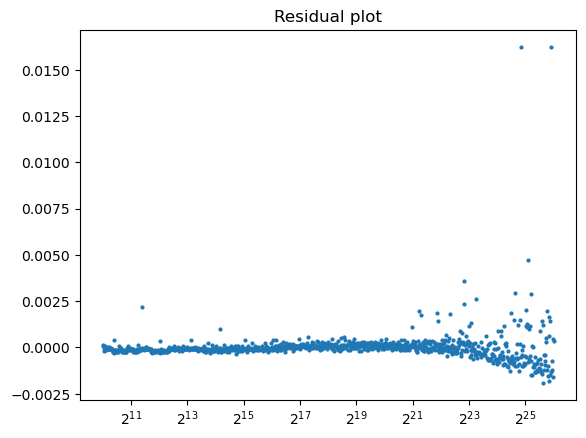

In [9]:
residual_plot(x, results)

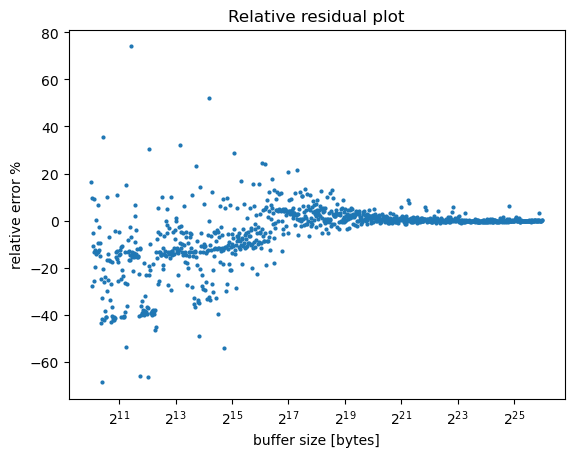

In [10]:
relative_residual_plot(x, y, results)

It seems that the model is biased on the smallest samples, consistently over predicting.
There could be cache effects, but the measurement overheads simply dominate the small buffer regimes.

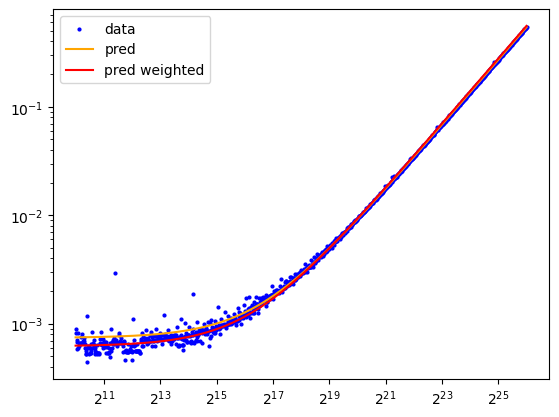

In [11]:
y_pred = results.predict(sm.add_constant(x))
y_pred_weighted = results_weighted.predict(sm.add_constant(x))

plt.scatter(x, y, s=4, c='blue', label='data')
plt.plot(x, y_pred, c='orange', label='pred')
plt.plot(x, y_pred_weighted, c='red', label='pred weighted')
plt.xscale('log', base=2)
plt.yscale('log')
plt.legend()
plt.show()

## Improved data quality
This section shows the benefit of a leaner runtime for the profiling of this type of applications. Throughput plots are compared between the python version and the C++ version

In [12]:
def add_throughput_column(df: pd.DataFrame, column_name: str = 'throughput_MB_s') -> None:
    if column_name in df.columns:
        return
    
    buffer_size_bytes = df['buffer_size_bytes']
    runtimes_s = df['runtime_s']

    throughput = buffer_size_bytes / runtimes_s
    throughput_MB_s = throughput / (2**20)

    df[column_name] = throughput_MB_s

In [13]:
for df in dataframes.values():
    add_throughput_column(df)

In [14]:
PYTHON_SUFFIX = '_python'
csv_pairs = []

names = set(dataframes.keys())
for name in names:
    if name.endswith(PYTHON_SUFFIX):
        basename = name.removesuffix(PYTHON_SUFFIX)
        if basename in names:
            csv_pairs.append((basename, name))

csv_pairs

[('radxa', 'radxa_python'), ('hp', 'hp_python'), ('pi', 'pi_python')]

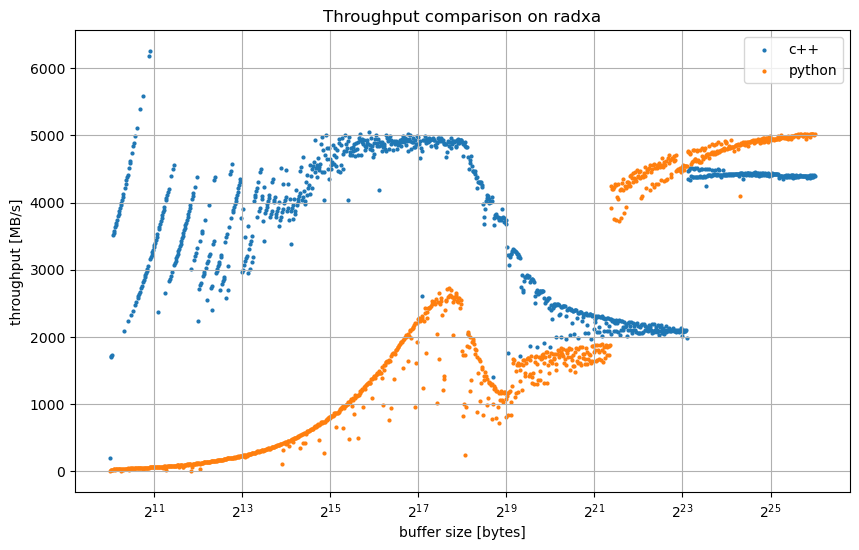

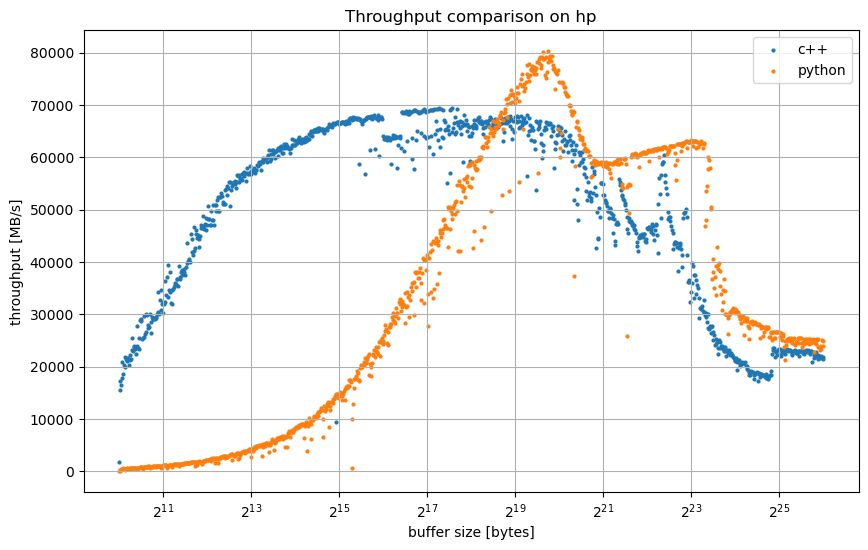

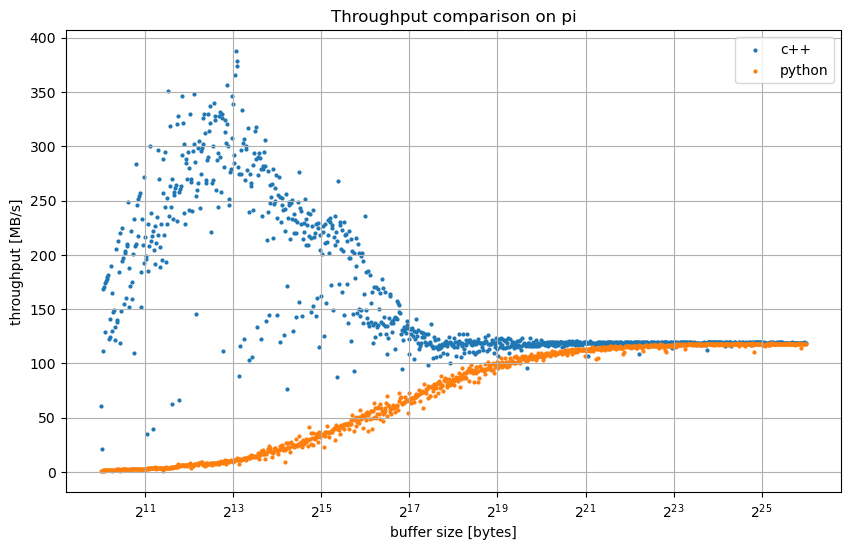

In [15]:
for (baseline_name, python_name) in csv_pairs:
    baseline_df = dataframes[baseline_name]
    python_df = dataframes[python_name]

    POINT_SIZE = 4

    fig, ax = plt.subplots(figsize=(10,6))

    ax.scatter(
        baseline_df['buffer_size_bytes'],
        baseline_df['throughput_MB_s'],
        s=POINT_SIZE,
        label='c++',
    )
    ax.scatter(
        python_df['buffer_size_bytes'],
        python_df['throughput_MB_s'],
        s=POINT_SIZE,
        label='python',
    )

    ax.set_title(f'Throughput comparison on {baseline_name}')
    ax.set_xscale('log', base=2)
    ax.set_xlabel('buffer size [bytes]')
    ax.set_ylabel('throughput [MB/s]')
    plt.legend()
    plt.grid()
    plt.show()

## A more robust data analysis
We found from empirical data that the C++ benchmark has smaller measurements overheads, but they are not negligible, particularly in the small buffer regimes. A possible remedy would be to model the kernel latency as a **piecewise linear function** of the buffer size.

$$ T(n) = \beta_0 + \beta_1(n) * n $$

where $\beta_1(n)$ is a piecewise constant function and the number of segments could be an hyperparameter of the model, to be chosen via cross validation.